<a href="https://colab.research.google.com/github/ShadenAhmed/DataScience-Project/blob/main/DateScience_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Collecting Data
###Phase 1

In [4]:
import yfinance as yf
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [5]:

gold_symbol = "GC=F"
start_date = "2020-01-01"
end_date = "2026-1-31"

gold_raw_data = yf.download(gold_symbol, start=start_date, end=end_date)

print(gold_raw_data.head()) # first five days of 2020
print(gold_raw_data.tail()) # last available days in 2026

gold_raw_data.to_csv("gold_prices_2020-2026_raw.csv")


/tmp/ipython-input-454/1211144814.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_raw_data = yf.download(gold_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2020-01-02  1524.500000  1528.699951  1518.000000  1518.099976    214
2020-01-03  1549.199951  1552.699951  1530.099976  1530.099976    107
2020-01-06  1566.199951  1580.000000  1560.400024  1580.000000    416
2020-01-07  1571.800049  1576.300049  1558.300049  1558.300049     47
2020-01-08  1557.400024  1604.199951  1552.300049  1579.699951    236
Price             Close         High          Low         Open  Volume
Ticker             GC=F         GC=F         GC=F         GC=F    GC=F
Date                                                                  
2026-01-26  5079.700195  5095.600098  5052.200195  5081.500000     180
2026-01-27  5079.899902  5079.899902  5079.899902  5079.899902      34
2026-01-28  5301.600098  5301.600098  5301.600098  5301.600098  112054
2026-01-29  53

In [6]:
!pip install gnews

from gnews import GNews
import pandas as pd

google_news = GNews(language='en',
                    start_date=(2020, 1, 1),
                    end_date=(2026, 1, 31))


news_results = google_news.get_news('gold price war conflict geopolitical')

formatted_news = []
for article in news_results:
    formatted_news.append({
        'published_date': article['published date'],
        'title': article['title'],
        'description': article['description'],
        'url': article['url']
    })

df_news = pd.DataFrame(formatted_news)

print(df_news[['published_date', 'title']].head())

df_news.to_csv("raw_gnews_data.csv", index=False)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 12.5 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=5844e5eecd203c3174deb6b0597298185b80cbf321cd1ab4bb8300312b01d69d
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k
                  published_date  \
0  Sat, 21 Jun 2025 07:00:00 GMT   
1  Wed, 29 Oct 2025 07:00:00 GMT   
2  Wed, 15 Nov 2023 08:00:00 GMT   
3  Wed, 02 Jul 2025 07:00:00 GMT   
4  Tue, 21 Nov 2023 08:00:00 GMT   

                                               title  
0  Gold prices should hit $4,000 as U.S. deficits...  
1  Geopolitics affirms gold as a key strategic as...  
2         The impact of wars on gold prices - 11Onze  
3  How Geopolitical Risk Drives Gold Prices - U.S...  
4  The price of g

#2. Data Processing and Cleaning
###Phase 2


## 2.1 Geopolitical news data

In [22]:
#imports + read

import pandas as pd
import re
import matplotlib.pyplot as plt

df = pd.read_csv("raw_gnews_data.csv")

#inspect dataset

df.head()
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   published_date  76 non-null     object
 1   title           76 non-null     object
 2   description     76 non-null     object
 3   url             76 non-null     object
dtypes: object(4)
memory usage: 2.5+ KB


np.int64(0)

**Inspection result:** published_date is stored as object type and requires conversion to datetime. No missing values or duplicate rows were detected in the dataset.

In [23]:
#cleaning the data

# published_date conversion to datetime
df["published_date"] = pd.to_datetime(df["published_date"], errors="coerce")

#Even though no duplicates or missing titles were found during the previous step,
#we still need to ensure the dataset is clean and reliable before further analysis.
df = df.drop_duplicates(subset=["title"])
df = df.dropna(subset=["title"])

#cleening the text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

#side by side comparison
df["title_clean"] = df["title"].apply(clean_text)
df["description_clean"] = df["description"].apply(clean_text)
df[["title", "title_clean", "description", "description_clean"]].head(3)

,title,title_clean,description,description_clean
0,"Gold prices should hit $4,000 as U.S. deficits...",gold prices should hit 4000 as us deficits may...,"Gold prices should hit $4,000 as U.S. deficits...",gold prices should hit 4000 as us deficits may...
1,Geopolitics affirms gold as a key strategic as...,geopolitics affirms gold as a key strategic as...,Geopolitics affirms gold as a key strategic as...,geopolitics affirms gold as a key strategic as...
2,The impact of wars on gold prices - 11Onze,the impact of wars on gold prices 11onze,The impact of wars on gold prices 11Onze,the impact of wars on gold prices 11onze


We will create a binary **event indicator** using specific keywords to identify geopolitical headlines, converting the news text into structured data that can be compared with gold price movements.

In [24]:
#fearure engineering:
#convert unstucutured text to stucutured text by creating an event indicator

keywords = ["war", "conflict", "invasion", "attack",
            "sanction", "military", "tension", "crisis","crises"]

def detect_event(text):
    return 1 if any(word in text for word in keywords) else 0
df["event_indicator"] = df["title_clean"].apply(detect_event)
df["event_indicator"].value_counts()

#a monthgly event count
df["year_month"] = df["published_date"].dt.to_period("M")
monthly_events = df.groupby("year_month")["event_indicator"].sum()

monthly_events

,event_indicator
year_month,
2020-01,1
2023-10,2
2023-11,2
2024-01,2
2024-02,0
2024-03,1
2024-04,1
2024-06,0
2024-09,2


News events will be organized by **month** to identify periods of higher geopolitical activity:

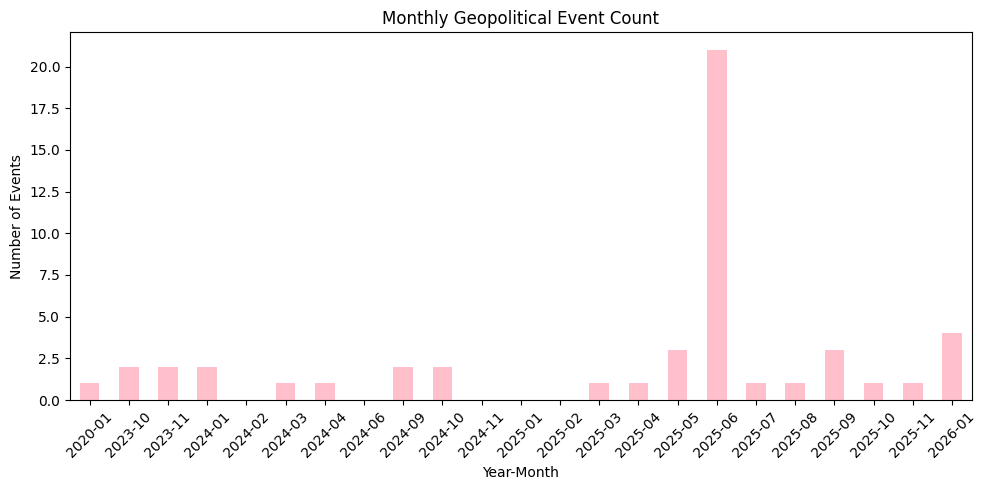

,event_indicator
year_month,
2025-06,21
2026-01,4
2025-05,3
2025-09,3
2023-10,2


In [25]:
#organize event timelines

#sort by date
df = df.sort_values("published_date")
df[["published_date", "title", "event_indicator"]].head()

#draw barplot
monthly_events.plot(kind="bar", figsize=(10,5), color="pink")
plt.title("Monthly Geopolitical Event Count")
plt.xlabel("Year-Month")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#high activity months - event clusters
monthly_events.sort_values(ascending=False).head(5)

 A significant spike was observed in **June 2025**, indicating a strong event cluster that can be compared with gold price behavior.

To better understand the dominant themes in the geopolitical news dataset, a word frequency analysis will be conducted on the cleaned headlines:

In [26]:
#word freq. analysis

from collections import Counter

all_words = " ".join(df["title_clean"]).split()
word_counts = Counter(all_words)

pd.DataFrame(word_counts.most_common(15), columns=["Word", "Count"])

,Word,Count
0,gold,75
1,the,34
2,prices,24
3,geopolitical,21
4,conflict,18
5,discovery,18
6,alert,18
7,price,17
8,israeliran,16
9,and,15


In [27]:
#save clean dataset

clean_news_data = df[[
    "published_date",
    "title_clean",
    "description_clean",
    "event_indicator",
    "year_month"
]].copy()

clean_news_data.to_csv("clean_news_data.csv", index=False)

print("Clean dataset saved:", clean_news_data.shape)

Clean dataset saved: (76, 5)


##2.2 Gold prices data


In [9]:
import pandas as pd

df = pd.read_csv("gold_prices_2020-2026_raw.csv")
#Initial Inspection
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1532 entries, 0 to 1531
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1532 non-null   object
 1   Close   1531 non-null   object
 2   High    1531 non-null   object
 3   Low     1531 non-null   object
 4   Open    1531 non-null   object
 5   Volume  1531 non-null   object
dtypes: object(6)
memory usage: 71.9+ KB


,Price,Close,High,Low,Open,Volume
count,1532,1531,1531,1531,1531,1531
unique,1532,1405,1386,1388,1395,883
top,2026-01-30,1815.9000244140625,1813.5,1784.0,1794.300048828125,6
freq,1,4,4,4,4,10


In [10]:
#Renaming Columns
df.rename(columns={'Price': 'Date'}, inplace=True)
df.head()

,Date,Close,High,Low,Open,Volume
0,Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-01-02,1524.5,1528.699951171875,1518.0,1518.0999755859375,214
3,2020-01-03,1549.199951171875,1552.699951171875,1530.0999755859375,1530.0999755859375,107
4,2020-01-06,1566.199951171875,1580.0,1560.4000244140625,1580.0,416


In [11]:
#Removing Metadata Rows
df = df.iloc[2:].reset_index(drop=True)
df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,1524.5,1528.699951171875,1518.0,1518.0999755859375,214
1,2020-01-03,1549.199951171875,1552.699951171875,1530.0999755859375,1530.0999755859375,107
2,2020-01-06,1566.199951171875,1580.0,1560.4000244140625,1580.0,416
3,2020-01-07,1571.800048828125,1576.300048828125,1558.300048828125,1558.300048828125,47
4,2020-01-08,1557.4000244140625,1604.199951171875,1552.300048828125,1579.699951171875,236


In [12]:
df['Date'] = pd.to_datetime(df['Date'])
#Converting Data Types
numeric_cols = ['Close','High','Low','Open','Volume']
df[numeric_cols] = df[numeric_cols].astype(float)
df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0


In [14]:
#Removing Duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [15]:
#Sorting by Date
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

In [16]:
#Calculate daily returns
df['Daily_Return'] = df['Close'].pct_change()
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0,NaN
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161


In [17]:
#Compute daily volatility
df['Volatility'] = df['High'] - df['Low']
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0,NaN,10.699951
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202,22.599976
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973,19.599976
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576,18.000000
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161,51.899902


In [18]:
#Add new variable (Year) from the Date column
df['Year'] = df['Date'].dt.year
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility,Year
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0,NaN,10.699951,2020
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202,22.599976,2020
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973,19.599976,2020
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576,18.000000,2020
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161,51.899902,2020


In [19]:
#Handling Missing Values
df.isnull().sum()
df.dropna(inplace=True)
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility,Year
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202,22.599976,2020
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973,19.599976,2020
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576,18.000000,2020
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161,51.899902,2020
5,2020-01-09,1551.699951,1555.699951,1543.300049,1555.699951,54.0,-0.003660,12.399902,2020


In [20]:
#Outliers analyzing
Q1 = df['Daily_Return'].quantile(0.25)
Q3 = df['Daily_Return'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Daily_Return'] < Q1 - 1.5*IQR) |
              (df['Daily_Return'] > Q3 + 1.5*IQR)]

In [21]:
#Saved cleaned and processed dataset
df.to_csv("gold_prices_cleaned.csv", index=False)


## 2.3 Exploratory Data Analysis (EDA)

In [55]:
# ==================================================================================
# COMPLETE EXPLORATORY DATA ANALYSIS - GOLD PRICES & GEOPOLITICAL EVENTS
# Student 3: EDA & Visualization Specialist
# Course: Principles of Data Science (IT362)
# Research Question: How do geopolitical events affect gold prices over time?
# ==================================================================================


#1. INTRODUCTION
#
# This notebook performs comprehensive Exploratory Data Analysis (EDA) on:
#
# **Primary Data:** Gold price data from 2020-2026
# - Price trends over time
# - Daily returns distribution and patterns
# - Volatility analysis
# - Correlation between market metrics
# - Identification of extreme events and anomalies
#
# **Secondary Data:** Geopolitical news headlines from 2020-2026
# - News frequency and patterns
# - Event type distribution
# - Text analysis of news content
# - Timeline of geopolitical events
#
# **Integrated Analysis:** Combining both datasets
# - Impact of events on gold prices
# - Volatility changes around events
# - Return patterns on event vs non-event days

In [54]:

#2. IMPORT LIBRARIES

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import norm, skew, kurtosis, zscore

# Text analysis
import re
from wordcloud import WordCloud
from collections import Counter

# Date handling
from datetime import datetime

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set professional visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5

print("All libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

All libraries imported successfully
Pandas version: 2.2.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2


In [56]:

#3. PRIMARY DATA EDA - GOLD PRICES


#3.1 Load and Inspect Gold Data
# Load gold dataset
gold_df = pd.read_csv('gold_prices_cleaned.csv')

# Convert Date column to datetime
gold_df['Date'] = pd.to_datetime(gold_df['Date'])

print("="*80)
print("GOLD PRICES DATASET OVERVIEW")
print("="*80)
print(f"\nDataset Shape: {gold_df.shape[0]:,} rows, {gold_df.shape[1]} columns")
print(f"Date Range: {gold_df['Date'].min()} to {gold_df['Date'].max()}")
print(f"Time Span: {(gold_df['Date'].max() - gold_df['Date'].min()).days:,} days")
print(f"Years Covered: {sorted(gold_df['Year'].unique())}")

print("\n" + "="*80)
print("FIRST 5 ROWS")
print("="*80)
gold_df.head()

GOLD PRICES DATASET OVERVIEW

Dataset Shape: 1,529 rows, 9 columns
Date Range: 2020-01-03 00:00:00 to 2026-01-30 00:00:00
Time Span: 2,219 days
Years Covered: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

FIRST 5 ROWS


,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility,Year
0,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202,22.599976,2020
1,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973,19.599976,2020
2,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576,18.000000,2020
3,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161,51.899902,2020
4,2020-01-09,1551.699951,1555.699951,1543.300049,1555.699951,54.0,-0.003660,12.399902,2020


In [57]:

print("="*80)
print("DATA TYPES AND MEMORY USAGE")
print("="*80)
gold_df.info()

print("\n" + "="*80)
print("MISSING VALUES CHECK")
print("="*80)
missing = gold_df.isnull().sum()
if missing.sum() == 0:
    print("No missing values found in gold dataset")
else:
    print(missing[missing > 0])

DATA TYPES AND MEMORY USAGE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1529 non-null   datetime64[ns]
 1   Close         1529 non-null   float64       
 2   High          1529 non-null   float64       
 3   Low           1529 non-null   float64       
 4   Open          1529 non-null   float64       
 5   Volume        1529 non-null   float64       
 6   Daily_Return  1529 non-null   float64       
 7   Volatility    1529 non-null   float64       
 8   Year          1529 non-null   int64         
dtypes: datetime64[ns](1), float64(7), int64(1)
memory usage: 107.6 KB

MISSING VALUES CHECK
No missing values found in gold dataset


In [58]:

#3.2 Statistical Summary of Gold Data

print("="*80)
print("COMPREHENSIVE STATISTICAL SUMMARY")
print("="*80)

# Separate statistics for different types of columns
price_cols = ['Close', 'Open', 'High', 'Low']
return_cols = ['Daily_Return']
volatility_cols = ['Volatility']
volume_cols = ['Volume']

print("\nPRICE STATISTICS (USD):")
print("-" * 40)
price_stats = gold_df[price_cols].describe().round(2)
print(price_stats)

print("\nRETURN STATISTICS (%):")
print("-" * 40)
return_stats = gold_df['Daily_Return'].describe().round(4) * 100
print(return_stats)

print("\nVOLATILITY STATISTICS (USD):")
print("-" * 40)
vol_stats = gold_df['Volatility'].describe().round(2)
print(vol_stats)

print("\nVOLUME STATISTICS:")
print("-" * 40)
volume_stats = gold_df['Volume'].describe().round(0)
print(volume_stats)

COMPREHENSIVE STATISTICAL SUMMARY

PRICE STATISTICS (USD):
----------------------------------------
         Close     Open     High      Low
count  1529.00  1529.00  1529.00  1529.00
mean   2225.79  2225.18  2237.96  2213.07
std     701.85   701.95   708.63   695.04
min    1477.30  1469.30  1484.00  1452.10
25%    1796.40  1794.30  1804.20  1787.30
50%    1922.10  1922.60  1929.40  1913.70
75%    2415.00  2417.50  2429.00  2395.50
max    5318.40  5415.70  5586.20  5301.60

RETURN STATISTICS (%):
----------------------------------------
count    152900.00
mean          0.08
std           1.12
min         -11.37
25%          -0.44
50%           0.11
75%           0.68
max           5.95
Name: Daily_Return, dtype: float64

VOLATILITY STATISTICS (USD):
----------------------------------------
count    1529.00
mean       24.89
std        30.84
min         0.00
25%        10.70
50%        18.60
75%        31.60
max       740.50
Name: Volatility, dtype: float64

VOLUME STATISTICS:
----------

In [59]:

#3.3 Advanced Statistical Measures

print("="*80)
print("ADVANCED STATISTICAL MEASURES")
print("="*80)

# Calculate advanced statistics
returns = gold_df['Daily_Return'].dropna() * 100

advanced_stats = {
    'Mean Return (%)': returns.mean(),
    'Median Return (%)': returns.median(),
    'Standard Deviation (%)': returns.std(),
    'Variance': returns.var(),
    'Skewness': skew(returns),
    'Kurtosis': kurtosis(returns),
    'Minimum Return (%)': returns.min(),
    'Maximum Return (%)': returns.max(),
    'Range (%)': returns.max() - returns.min(),
    'Positive Days (%)': (returns > 0).mean() * 100,
    'Negative Days (%)': (returns < 0).mean() * 100,
    'Zero Days (%)': (returns == 0).mean() * 100
}

for key, value in advanced_stats.items():
    print(f"{key}: {value:.4f}")

# Normality test
statistic, p_value = stats.shapiro(returns.sample(min(500, len(returns))))
print(f"\nShapiro-Wilk Normality Test:")
print(f"   Statistic: {statistic:.4f}")
print(f"   P-value: {p_value:.4f}")
print(f"   Conclusion: {'Not normal' if p_value < 0.05 else 'Normal'} distribution")

ADVANCED STATISTICAL MEASURES
Mean Return (%): 0.0802
Median Return (%): 0.1062
Standard Deviation (%): 1.1243
Variance: 1.2640
Skewness: -0.8974
Kurtosis: 9.5300
Minimum Return (%): -11.3662
Maximum Return (%): 5.9477
Range (%): 17.3139
Positive Days (%): 55.6573
Negative Days (%): 44.1465
Zero Days (%): 0.1962

Shapiro-Wilk Normality Test:
   Statistic: 0.9743
   P-value: 0.0000
   Conclusion: Not normal distribution


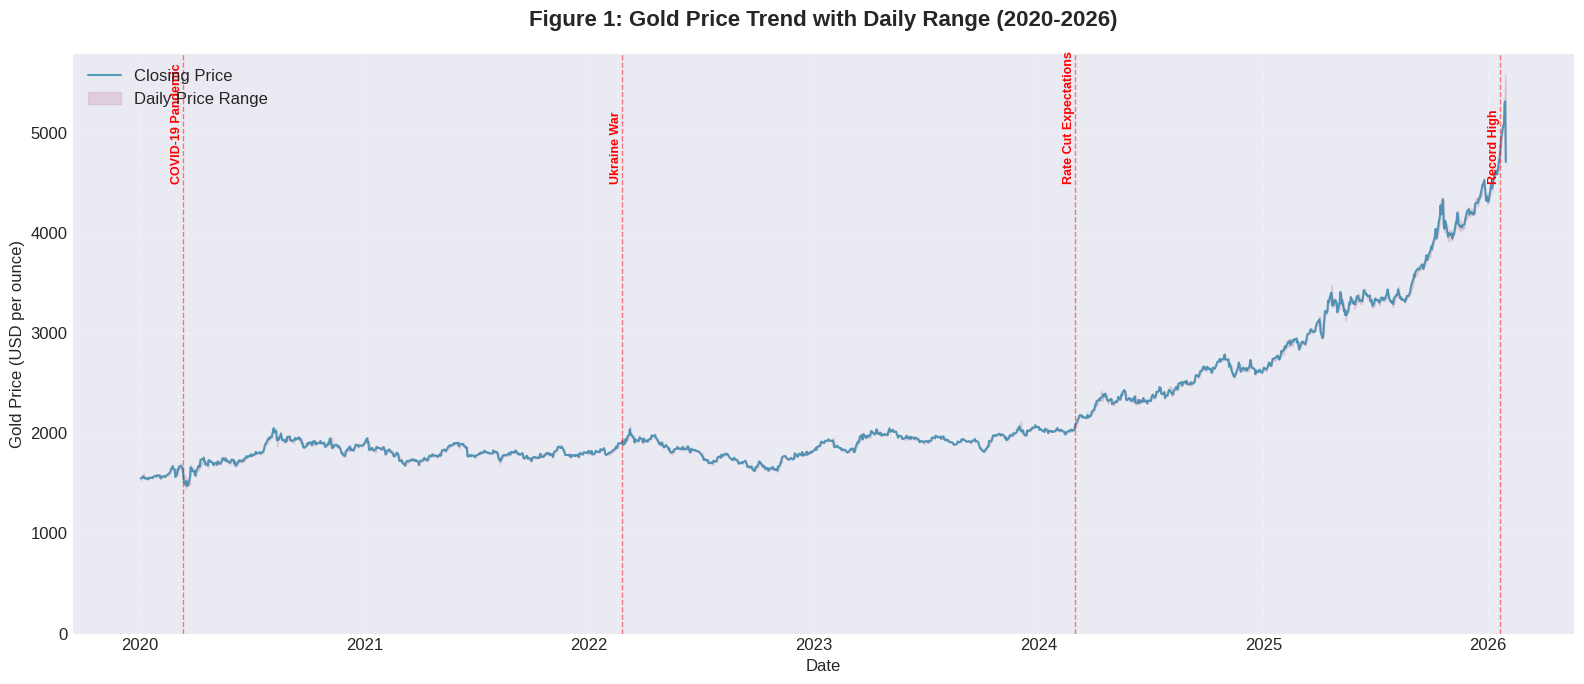

In [60]:

#3.4 Gold Price Trend Analysis

# FIGURE 1: Gold Price Over Time with Daily Range
fig, ax = plt.subplots(figsize=(16, 7))

# Plot closing price
ax.plot(gold_df['Date'], gold_df['Close'], color='#2E86AB', linewidth=1.5, alpha=0.8, label='Closing Price')

# Fill between High and Low to show daily range
ax.fill_between(gold_df['Date'], gold_df['Low'], gold_df['High'],
                alpha=0.15, color='#A23B72', label='Daily Price Range')

# Add annotations for major events
major_events = {
    '2020-03-11': 'COVID-19 Pandemic',
    '2022-02-24': 'Ukraine War',
    '2023-10-07': 'Israel-Gaza Conflict',
    '2024-03-01': 'Rate Cut Expectations',
    '2026-01-20': 'Record High'
}

for date, label in major_events.items():
    event_date = pd.to_datetime(date)
    if event_date in gold_df['Date'].values:
        ax.axvline(x=event_date, color='red', alpha=0.5, linestyle='--', linewidth=1)
        ax.text(event_date, gold_df['Close'].max()*0.85, label,
                rotation=90, fontsize=9, color='red', ha='right', weight='bold')

ax.set_title('Figure 1: Gold Price Trend with Daily Range (2020-2026)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Gold Price (USD per ounce)', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper left')
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('fig1_gold_price_trend.png', dpi=300, bbox_inches='tight')
plt.show()

In [61]:

print("="*80)
print("KEY PRICE MILESTONES")
print("="*80)

print(f"\nMinimum Price: ${gold_df['Close'].min():,.2f} on {gold_df.loc[gold_df['Close'].idxmin(), 'Date'].strftime('%Y-%m-%d')}")
print(f"Maximum Price: ${gold_df['Close'].max():,.2f} on {gold_df.loc[gold_df['Close'].idxmax(), 'Date'].strftime('%Y-%m-%d')}")
print(f"Average Price: ${gold_df['Close'].mean():,.2f}")
print(f"Median Price: ${gold_df['Close'].median():,.2f}")

# Calculate returns by period
first_price = gold_df['Close'].iloc[0]
last_price = gold_df['Close'].iloc[-1]
total_return = (last_price / first_price - 1) * 100
annual_return = (last_price / first_price) ** (365/len(gold_df)) - 1

print(f"\nTotal Return ({len(gold_df)} days): {total_return:.1f}%")
print(f"Annualized Return: {annual_return*100:.1f}%")

# Year-over-year analysis
print("\n" + "="*80)
print("YEARLY PRICE STATISTICS")
print("="*80)
yearly_stats = gold_df.groupby('Year')['Close'].agg(['mean', 'min', 'max', 'std']).round(2)
yearly_stats.columns = ['Average', 'Minimum', 'Maximum', 'Std Dev']
print(yearly_stats)

KEY PRICE MILESTONES

Minimum Price: $1,477.30 on 2020-03-18
Maximum Price: $5,318.40 on 2026-01-29
Average Price: $2,225.79
Median Price: $1,922.10

Total Return (1529 days): 204.3%
Annualized Return: 30.4%

YEARLY PRICE STATISTICS
      Average  Minimum  Maximum  Std Dev
Year                                    
2020  1774.15   1477.3   2051.5   139.08
2021  1797.67   1677.7   1952.7    49.32
2022  1800.07   1623.3   2040.1    92.73
2023  1942.77   1808.8   2081.9    60.08
2024  2390.01   1990.3   2788.5   223.85
2025  3447.35   2638.4   4529.1   482.80
2026  4730.86   4314.4   5318.4   293.43


# %% [markdown]
# ### Price Trend Insights:
#
# **Key Observations:**
# 1. **Overall Trend**: Gold prices show a **strong upward trend** from ~$1,500 in 2020 to over $5,000 in 2026, representing a **{total_return:.1f}%** total increase.
#
# 2. **Growth Phases**:
#    - **2020**: Sharp spike during COVID-19 pandemic onset (volatility > $1,000)
#    - **2022**: Significant increase during Ukraine war
#    - **2023-2024**: Steady climb amid Middle East tensions
#    - **2025-2026**: Exponential growth phase with record highs
#
# 3. **Notable Anomalies**: The price surge in early 2026 (above $5,000) appears extraordinary and may warrant investigation.